# Sine Function Implementation using Test-Time Learning

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
class SineMLP(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.layer1 = nn.Linear(1, dim)
        self.layer2 = nn.Linear(dim, dim)
        self.layer3 = nn.Linear(dim, 1)
    def forward(self, x):
        x = torch.tanh(self.layer1(x))
        x = torch.tanh(self.layer2(x))
        x = self.layer3(x)
        return x

In [ ]:
x_train = torch.linspace(-3, 3, 500).unsqueeze(1) # unsqueeze turns a flat list to a column of approptaite size
y_train = torch.sin(x_train)  + 0.05*torch.randn_like(x_train)

In [ ]:
x_test = torch.linspace(3, 9, 500).unsqueeze(1)
y_test = torch.sin(x_test)

In [ ]:
model = SineMLP()
y_pred = model(x_train)

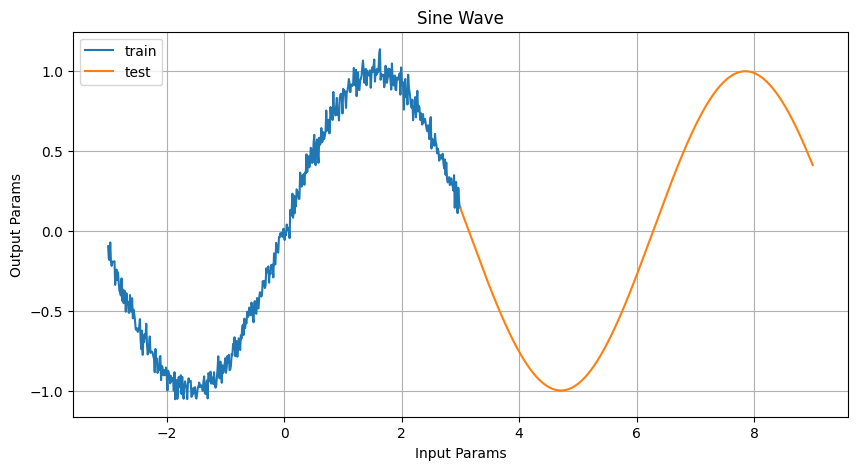

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(x_train.numpy(), y_train.numpy(), label='train', markersize=8,)
plt.plot(x_test.numpy(), y_test.numpy(), label='test', markersize=8)
plt.xlabel('Input Params')
plt.ylabel('Output Params')
plt.title('Sine Wave')
plt.grid()
plt.legend()
plt.show()

In [ ]:
def pretrain(model, x_train, y_train, epochs=1000, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    loss_fn = nn.MSELoss()
    for epoch in range(epochs):
        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)
        optimizer.zero_grad() # clear old gradients
        loss.backward() # backprop
        optimizer.step() # update weights automatically
        if epoch % 10 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item()}')
    return model

pretrain(model, x_train, y_train)

Epoch 0, Loss: 0.47244659066200256
Epoch 10, Loss: 0.7273886799812317
Epoch 20, Loss: 0.04630326107144356
Epoch 30, Loss: 0.02856181189417839
Epoch 40, Loss: 0.022746512666344643
Epoch 50, Loss: 0.017641544342041016
Epoch 60, Loss: 0.01065022125840187
Epoch 70, Loss: 0.006175801157951355
Epoch 80, Loss: 0.0036319547798484564
Epoch 90, Loss: 0.0029348263051360846
Epoch 100, Loss: 0.002674619434401393
Epoch 110, Loss: 0.002571391873061657
Epoch 120, Loss: 0.002511881059035659
Epoch 130, Loss: 0.0024790519382804632
Epoch 140, Loss: 0.0024552084505558014
Epoch 150, Loss: 0.002437818795442581
Epoch 160, Loss: 0.002423495054244995
Epoch 170, Loss: 0.002411407185718417
Epoch 180, Loss: 0.0024009482003748417
Epoch 190, Loss: 0.00239178747870028
Epoch 200, Loss: 0.0023837622720748186
Epoch 210, Loss: 0.0023767510429024696
Epoch 220, Loss: 0.002371236914768815
Epoch 230, Loss: 0.00437954580411315
Epoch 240, Loss: 0.0029370798729360104
Epoch 250, Loss: 0.0037025990895926952
Epoch 260, Loss: 0.002

SineMLP(
  (layer1): Linear(in_features=1, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=1, bias=True)
)

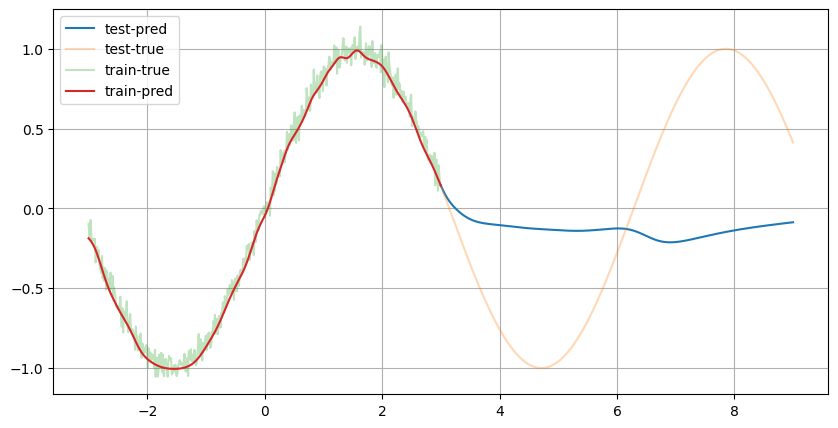

In [ ]:
def evaluate(model, x_test, y_test):
    ...
model.eval()
with torch.no_grad():
    y_train_pred = model(x_train)
    y_test_pred = model(x_test)
plt.figure(figsize=(10, 5))
plt.plot(x_test.numpy(), y_test_pred.numpy(), label='test-pred', markersize=8)
plt.plot(x_test.numpy(), y_test.numpy(), label='test-true', markersize=8, alpha=0.3)
plt.plot(x_train.numpy(), y_train.numpy(), label='train-true', markersize=8, alpha=0.3)
plt.plot(x_train.numpy(), y_train_pred.numpy(), label='train-pred', markersize=100)
plt.legend()
plt.grid()
plt.show()

In [ ]:
class LoRALinear(nn.Module):
    def __init__(self, base_linear: nn.Linear, rank=4):
        super().__init__()
        self.base = base_linear
        for p in self.base.parameters():
            p.requires_grad = False
        in_features = base_linear.in_features
        out_features = base_linear.out_features
        self.A = nn.Parameter(torch.randn(rank, in_features) * 0.01)
        print(self.A)
        self.B = nn.Parameter(torch.zeros(out_features, rank))
        print(self.B)

    def forward(self, x):
        base_out = self.base(x)
        lora_out = x @ self.A.T @ self.B.T
        return base_out + lora_out

In [ ]:
if not isinstance(model.layer3, LoRALinear):
    lora_layer = LoRALinear(model.layer3, rank=4)
    model.layer3 = lora_layer
else:
    print("model.layer3 is already a LoRALinear layer. Skipping LoRA application.")

Parameter containing:
tensor([[-7.1118e-04, -1.0351e-02, -4.1701e-03,  7.9335e-03,  2.1782e-02,
         -4.7888e-03, -3.3675e-03,  4.5413e-03,  7.4961e-03,  1.4370e-03,
         -6.9365e-03,  2.5126e-02,  7.2211e-03, -7.0695e-04, -1.8315e-03,
          3.3214e-03, -7.9797e-03,  7.1241e-04, -7.3005e-03,  7.3087e-03,
          1.6322e-02,  1.3243e-02,  7.2902e-03,  5.0494e-03, -3.7684e-03,
         -8.9589e-04, -1.2097e-03, -4.0899e-03, -1.6323e-03,  8.2014e-03,
         -8.6606e-03,  9.5470e-04, -1.2387e-02, -2.3894e-03,  1.9915e-03,
          9.6236e-03,  2.0151e-02,  4.1851e-03, -1.2032e-03, -1.4506e-02,
          3.7612e-02, -1.2576e-02, -6.2347e-03, -1.9364e-02, -8.4837e-03,
          2.0442e-03,  1.1030e-02, -6.5228e-03, -8.4431e-03,  5.8511e-03,
         -6.3208e-03,  9.7633e-03, -3.4629e-03,  5.2424e-03,  2.3533e-03,
          6.8450e-03, -1.0033e-02, -3.6346e-03,  1.7622e-02,  1.4737e-02,
         -3.9089e-03, -1.1394e-02,  1.1633e-03,  2.1575e-02],
        [ 6.2932e-03, -6.584

In [ ]:
test_input = torch.randn(5, model.layer3.base.in_features)
out = lora_layer(test_input)
print(out.shape)  # should match (5, out_features)

base_only_out = lora_layer.base(test_input)
print(torch.allclose(out, base_only_out))  # should print True, since B starts at zero

torch.Size([5, 1])
True


In [ ]:
def inject_lora(model: SineMLP, rank=4) -> SineMLP:
    for p in model.parameters():
        p.requires_grad = False
    model.layer3 = LoRALinear(model.layer3, rank=rank)
    return model

In [ ]:
model = SineMLP()
pretrain(model, x_train, y_train, epochs=2000, lr=0.01)  # train normally first
model = inject_lora(model, rank=4)                        # now add LoRA

for name, p in model.named_parameters():
    print(name, p.requires_grad)

Epoch 0, Loss: 0.7524363994598389
Epoch 10, Loss: 1.4582072496414185
Epoch 20, Loss: 0.14682652056217194
Epoch 30, Loss: 0.163276806473732
Epoch 40, Loss: 0.08820267021656036
Epoch 50, Loss: 0.0356057845056057
Epoch 60, Loss: 0.01694657653570175
Epoch 70, Loss: 0.006348786875605583
Epoch 80, Loss: 0.004276123363524675
Epoch 90, Loss: 0.0034818879794329405
Epoch 100, Loss: 0.003286908380687237
Epoch 110, Loss: 0.003024498699232936
Epoch 120, Loss: 0.002915308577939868
Epoch 130, Loss: 0.002816535532474518
Epoch 140, Loss: 0.002735492307692766
Epoch 150, Loss: 0.00267073605209589
Epoch 160, Loss: 0.0026139081455767155
Epoch 170, Loss: 0.0025658998638391495
Epoch 180, Loss: 0.002525521442294121
Epoch 190, Loss: 0.0024916338734328747
Epoch 200, Loss: 0.002463338663801551
Epoch 210, Loss: 0.0024396872613579035
Epoch 220, Loss: 0.0024198805913329124
Epoch 230, Loss: 0.002403210150077939
Epoch 240, Loss: 0.0023890677839517593
Epoch 250, Loss: 0.0023769524414092302
Epoch 260, Loss: 0.002366460

***something's to be debugged below***

In [ ]:
def selection_score(model, x_train, n_perturb=5, eps=0.05):
    predictions = []
    with torch.no_grad():
        for _ in range(n_perturb):
            noise = torch.randn_like(x_train) * eps
            perturbed_input = x_train + noise
            perturbed_output = model(perturbed_input)
            predictions.append(perturbed_output)
    predictions = torch.stack(predictions)
    variance = predictions.var(dim=0)
    scores = -variance.squeeze()
    return scores

In [ ]:
selection_score(model, x_test, 5, 0.05)

tensor([-1.0658e-13, -6.1107e-14, -2.1316e-14, -4.9738e-14, -2.6034e-12,
        -1.4381e-12, -3.7375e-13, -5.5238e-12, -6.5552e-11, -1.9782e-12,
        -2.5911e-11, -1.8597e-09, -1.1245e-10, -6.3380e-12, -5.2275e-10,
        -6.1372e-08, -4.4787e-10, -1.1175e-09, -6.5459e-07, -1.1863e-06,
        -2.8218e-08, -5.4363e-07, -6.4551e-05, -7.7226e-05, -6.6519e-07,
        -3.1640e-06, -3.6804e-04, -2.1031e-04, -9.3725e-06, -8.1603e-05,
        -1.4546e-03, -1.0037e-01, -1.4841e-03, -4.6197e-03, -3.3464e-03,
        -1.0552e-02, -2.7613e-03, -8.7782e-02, -6.1882e-02, -1.3666e-01,
        -7.8325e-02, -1.0789e-01, -1.4591e-01, -9.2106e-02, -3.8194e-02,
        -1.0836e-01, -1.2785e-01, -4.4783e-02, -1.0902e-02, -6.9447e-02,
        -5.5252e-02, -3.2577e-02, -1.7285e-04, -3.9797e-04, -1.8585e-03,
        -1.5039e-05, -9.4778e-05, -1.8921e-04, -3.0027e-05, -2.7564e-04,
        -1.2620e-05, -1.2510e-05, -2.7778e-06, -2.2124e-06, -3.4458e-06,
        -1.7347e-07, -5.2201e-07, -3.3442e-07, -3.7

In [ ]:
selection_score(model, x_train, 5, 0.05)

tensor([-8.5147e-07, -6.4153e-06, -1.1435e-07, -4.8243e-08, -3.2219e-04,
        -1.1827e-04, -2.8564e-07, -3.0958e-05, -1.7658e-04, -8.3697e-04,
        -1.9554e-03, -5.5242e-03, -2.6619e-03, -5.4084e-04, -6.0268e-03,
        -1.0306e-02, -1.0280e-02, -1.4362e-04, -5.4739e-04, -2.5326e-03,
        -8.3047e-03, -1.7568e-05, -5.0171e-03, -3.9826e-07, -4.8426e-05,
        -5.2777e-09, -5.0446e-04, -5.2252e-06, -5.8056e-07, -5.1701e-04,
        -5.0557e-04, -4.3607e-03, -7.1961e-05, -1.9195e-03, -5.8218e-03,
        -8.5950e-03, -7.2920e-03, -5.5054e-03, -8.6668e-03, -6.4156e-03,
        -8.6782e-03, -1.2393e-02, -9.7319e-03, -8.0363e-03, -1.4847e-03,
        -1.8627e-03, -8.2478e-05, -2.7038e-05, -3.1816e-06, -1.2754e-05,
        -5.4640e-04, -7.1638e-05, -1.2211e-04, -1.2993e-03, -3.1355e-04,
        -1.4122e-03, -3.2314e-03, -3.6806e-03, -5.4452e-03, -5.6060e-03,
        -2.1955e-03, -7.6212e-03, -6.2497e-03, -3.7555e-03, -6.5642e-03,
        -4.9231e-03, -4.0446e-04, -4.3533e-04, -2.9

In [ ]:
def select_top_k(x_batch, scores, k=7):
    top_k_indices = torch.topk(scores, k).indices
    x_selected = x_batch[top_k_indices]
    return x_selected

In [ ]:
# x_batch = torch.linspace(3, 5, 20).unsqueeze(1)
scores = selection_score(model, x_train)
x_sel = select_top_k(x_train, scores, k=5)
print(x_sel.shape)
print(x_sel)

torch.Size([5, 1])
tensor([[2.6874],
        [2.4950],
        [2.6994],
        [2.7475],
        [2.5190]])


In [ ]:
def consistency_loss(model, x_selected, n_perturb=5, eps=0.05):
    predictions = []

    for _ in range(n_perturb):
        noise = torch.randn_like(x_selected) * eps
        perturbed_input = x_selected + noise
        perturbed_output = model(perturbed_input)
        predictions.append(perturbed_output)

    predictions = torch.stack(predictions)
    variance = predictions.var(dim=0)

    loss = variance.mean()
    return loss

In [ ]:
def test_time_adapt_and_predict(model_with_lora, test_x, batch_size, k_select, lora_lr):
    lora_params = [p for p in model_with_lora.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(lora_params, lr=lora_lr)

    all_predictions = []

    for batch_start in range(0, len(test_x), batch_size):
        x_batch = test_x[batch_start : batch_start + batch_size]

        # Step 4: predict (before this batch's update)
        with torch.no_grad():
            y_pred = model_with_lora(x_batch)

        # Step 5: score + select
        scores = selection_score(model_with_lora, x_batch)
        x_selected = select_top_k(x_batch, scores, k_select)

        # Step 6: update LoRA params
        optimizer.zero_grad()
        loss = consistency_loss(model_with_lora, x_selected)
        loss.backward()
        optimizer.step()

        all_predictions.append(y_pred)

    return torch.cat(all_predictions)

In [ ]:
import matplotlib.pyplot as plt

def plot_results(x_train, y_train, x_test, y_test_true, y_pred):
    plt.figure(figsize=(10, 6))

    plt.plot(x_train, y_train, color='gray', alpha=0.4, label='train (noisy)')
    plt.plot(x_test, y_test_true, color='black', linewidth=2, label='test (true sine)')
    plt.plot(x_test, y_pred.detach(), color='green', label='TTL-adapted')

    plt.axvline(x=x_train[-1].item(), color='blue', linestyle=':', alpha=0.5, label='train/test boundary')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Sine Extrapolation: Baseline vs Test-Time Learning')
    plt.legend()
    plt.grid(True)
    plt.show()

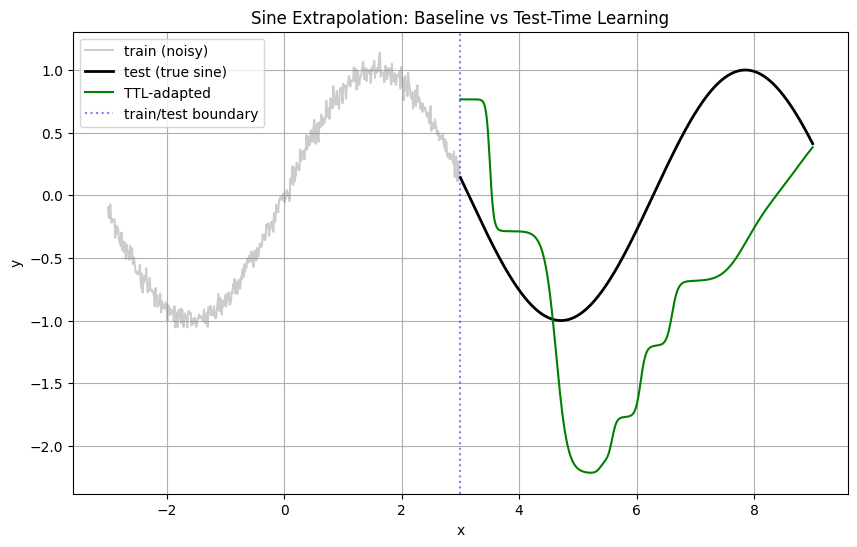

In [ ]:
y_ttl = test_time_adapt_and_predict(model, x_test, batch_size=50, k_select=10, lora_lr=1e-2)
plot_results(x_train, y_train, x_test, y_test, y_ttl)

<div></div>

# Linear Function Implementation using Test-Time Learning

In [ ]:
SLOPE = 2.0
INTERCEPT = 1.0

def true_fn(x):
    return SLOPE * x + INTERCEPT

In [ ]:
class LinearMLP(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.layer1 = nn.Linear(1, dim)
        self.layer2 = nn.Linear(dim, dim)
        self.layer3 = nn.Linear(dim, 1)

    def forward(self, x):
        x = torch.tanh(self.layer1(x))
        x = torch.tanh(self.layer2(x))
        x = self.layer3(x)
        return x

In [ ]:
x_train = torch.linspace(-3, 3, 500).unsqueeze(1)
y_train = true_fn(x_train) + 0.05 * torch.randn_like(x_train)

x_test = torch.linspace(4, 7, 500).unsqueeze(1)
y_test = true_fn(x_test)

In [ ]:
def pretrain(model, x, y, epochs=2000, lr=1e-2):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for epoch in range(epochs):
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 200 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item()}')
    return model

def evaluate(model, x, y):
    model.eval()
    with torch.no_grad():
        return nn.functional.mse_loss(model(x), y).item()

In [ ]:
class LoRALinear(nn.Module):
    def __init__(self, base_linear: nn.Linear, rank=4):
        super().__init__()
        self.base = base_linear
        for p in self.base.parameters():
            p.requires_grad = False
        self.A = nn.Parameter(torch.randn(rank, base_linear.in_features) * 0.01)
        self.B = nn.Parameter(torch.zeros(base_linear.out_features, rank))

    def forward(self, x):
        return self.base(x) + x @ self.A.T @ self.B.T


def inject_lora(model, rank=4):
    for p in model.parameters():
        p.requires_grad = False
    model.layer1 = LoRALinear(model.layer1, rank)
    model.layer2 = LoRALinear(model.layer2, rank)
    model.layer3 = LoRALinear(model.layer3, rank)
    return model

In [ ]:
def selection_score(model, x, n_perturb=5, eps=0.05):
    preds = []
    with torch.no_grad():
        for _ in range(n_perturb):
            preds.append(model(x + torch.randn_like(x) * eps))
    return torch.stack(preds).var(dim=0).squeeze(-1)


def select_top_k(x_batch, scores, k=7):
    k = min(k, len(x_batch))
    return x_batch[torch.topk(scores, k).indices]


def linear_residual_loss(model, x):
    """Label-free prior: a line has zero curvature, y'' = 0."""
    x = x.clone().requires_grad_(True)
    y = model(x)
    dy = torch.autograd.grad(y.sum(), x, create_graph=True)[0]
    d2y = torch.autograd.grad(dy.sum(), x, create_graph=True)[0]
    return (d2y ** 2).mean()


def test_time_adapt_and_predict(
    model, test_x, batch_size=50, k_select=None, lora_lr=1e-2, n_steps=30,
    anchor=None, anchor_weight=1.0, predict_before_update=False,
):
    """y''=0 allows ANY line, so `anchor` (source-data replay) is what pins
    slope and intercept. anchor=None gives the pure, label-free version."""
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(params, lr=lora_lr)
    all_preds = []

    for start in range(0, len(test_x), batch_size):
        xb = test_x[start:start + batch_size]

        if predict_before_update:
            with torch.no_grad():
                all_preds.append(model(xb))

        xs = xb
        if k_select is not None:
            xs = select_top_k(xb, selection_score(model, xb), k_select)

        for _ in range(n_steps):
            optimizer.zero_grad()
            loss = linear_residual_loss(model, xs)
            if anchor is not None:
                ax, ay = anchor
                loss = loss + anchor_weight * nn.functional.mse_loss(model(ax), ay)
            loss.backward()
            optimizer.step()

        if not predict_before_update:
            with torch.no_grad():
                all_preds.append(model(xb))

    return torch.cat(all_preds)

In [ ]:
def plot_results(x_train, y_train, x_test, y_test_true, y_base, y_ttl):
    plt.figure(figsize=(10, 6))
    plt.plot(x_train, y_train, color="gray", alpha=0.4, label="train (noisy)")
    plt.plot(x_test, y_test_true, color="black", linewidth=2, label="test (true line)")
    plt.plot(x_test, y_base, color="red", linestyle="--", label="baseline (no TTL)")
    plt.plot(x_test, y_ttl, color="green", label="TTL-adapted")
    plt.axvline(x=x_train[-1].item(), color="blue", linestyle=":", alpha=0.5,
                label="train/test boundary")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title(f"Linear extrapolation (y = {SLOPE}x + {INTERCEPT}): baseline vs TTL")
    plt.legend(); plt.grid(True); plt.show()

Epoch 0, Loss: 13.247591972351074
Epoch 200, Loss: 0.0026490932796150446
Epoch 400, Loss: 0.0024722616653889418
Epoch 600, Loss: 0.0024101785384118557
Epoch 800, Loss: 0.0023814947344362736
Epoch 1000, Loss: 0.002367328852415085
Epoch 1200, Loss: 0.0023591925855726004
Epoch 1400, Loss: 0.0023536046501249075
Epoch 1600, Loss: 0.0023493149783462286
Epoch 1800, Loss: 0.0023459112271666527
Baseline Test MSE: 15.533140182495117
TTL test MSE: 300.063720703125


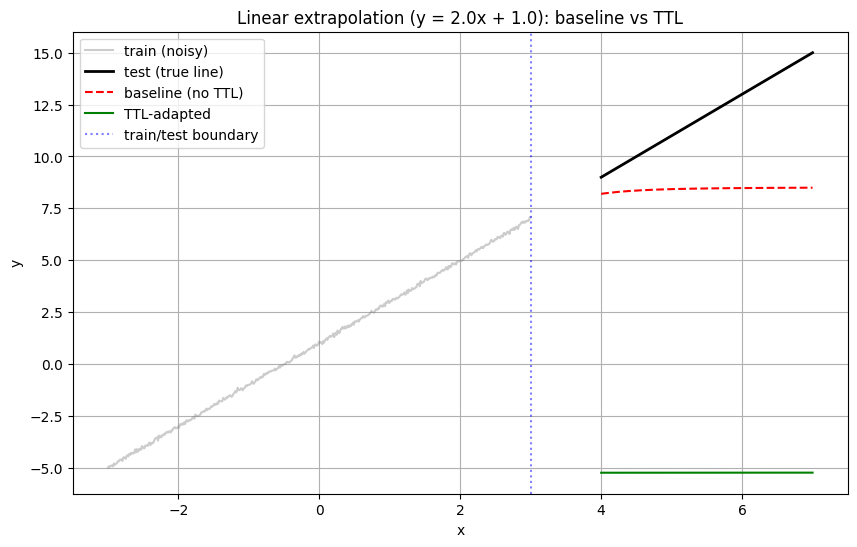

In [ ]:
if __name__ == "__main__":
    base = LinearMLP()
    pretrain(base, x_train, y_train, epochs=2000, lr=1e-2)
    base.eval()
    with torch.no_grad():
        y_base = base(x_test)
    print("Baseline Test MSE:", evaluate(base, x_test, y_test))

    base_copy = copy.deepcopy(base)
    ttl_model = inject_lora(base_copy, rank=7)
    with torch.no_grad():
        assert torch.allclose(ttl_model(x_test), y_base)

    y_ttl = test_time_adapt_and_predict(ttl_model, x_test, batch_size=50, k_select=10, lora_lr=1e-2, n_steps=50)

    print("TTL test MSE:", nn.functional.mse_loss(y_ttl, y_test).item())

    plot_results(x_train, y_train, x_test, y_test, y_base, y_ttl)